# معالجة البيانات الأولية لمجموعة بيانات نمط حياة الطلاب

## نظرة عامة
هذا الدفتر يوضح خطوات معالجة البيانات الأولية (Preprocessing) لمجموعة بيانات نمط حياة الطلاب وعلاقتها بالاكتئاب. سنقوم بفحص البيانات، تنظيفها، ترميزها، وتقسيمها للتحضير للتدريب على نماذج التعلم الآلي.

## 1. استيراد المكتبات
نستورد المكتبات المطلوبة للتحليل والمعالجة:
- **pandas**: للتعامل مع البيانات الجدولية
- **matplotlib**: لإنشاء الرسوم البيانية
- **scikit-learn**: للمعالجة والتقسيم والتوحيد

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
%matplotlib inline

## 2. تحميل البيانات
نقوم بتحميل مجموعة البيانات من ملف CSV الذي يحتوي على معلومات عن نمط حياة الطلاب.

In [38]:
df = pd.read_csv('/Users/khawlh/Desktop/un/ML/university students ml/data/student_lifestyle_100k.csv')


## 3. الفحص الأولي للبيانات
نفحص البيانات الأولية: عرض العينة الأولى، حجم البيانات، أنواع البيانات، والإحصائيات الأساسية.

In [39]:
from IPython.display import display

display(df.head())

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

display(df.describe().style.format("{:.2f}").set_caption("إحصائيات أساسية للبيانات"))

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Shape: (100000, 11)

Data Types:
Student_ID              int64
Age                     int64
Gender                    str
Department                str
CGPA                  float64
Sleep_Duration        float64
Study_Hours           float64
Social_Media_Hours    float64
Physical_Activity       int64
Stress_Level            int64
Depression               bool
dtype: object


,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,51000.50,21.01,2.90,7.00,4.51,3.50,74.35,4.13
std,28867.66,2.00,0.53,1.50,1.98,1.49,43.37,1.42
min,1001.00,18.00,1.56,3.00,0.00,0.00,0.00,2.00
25%,26000.75,19.00,2.45,6.00,3.20,2.50,37.00,3.00
50%,51000.50,21.00,2.90,7.00,4.50,3.50,74.00,4.00
75%,76000.25,23.00,3.35,8.00,5.80,4.50,112.00,5.00
max,101000.00,24.00,4.00,12.00,12.80,10.00,149.00,10.00


## 4. توزيع الخصائص
نعرض توزيع جميع الخصائص الرقمية باستخدام الرسوم البيانية لفهم توزيع البيانات.

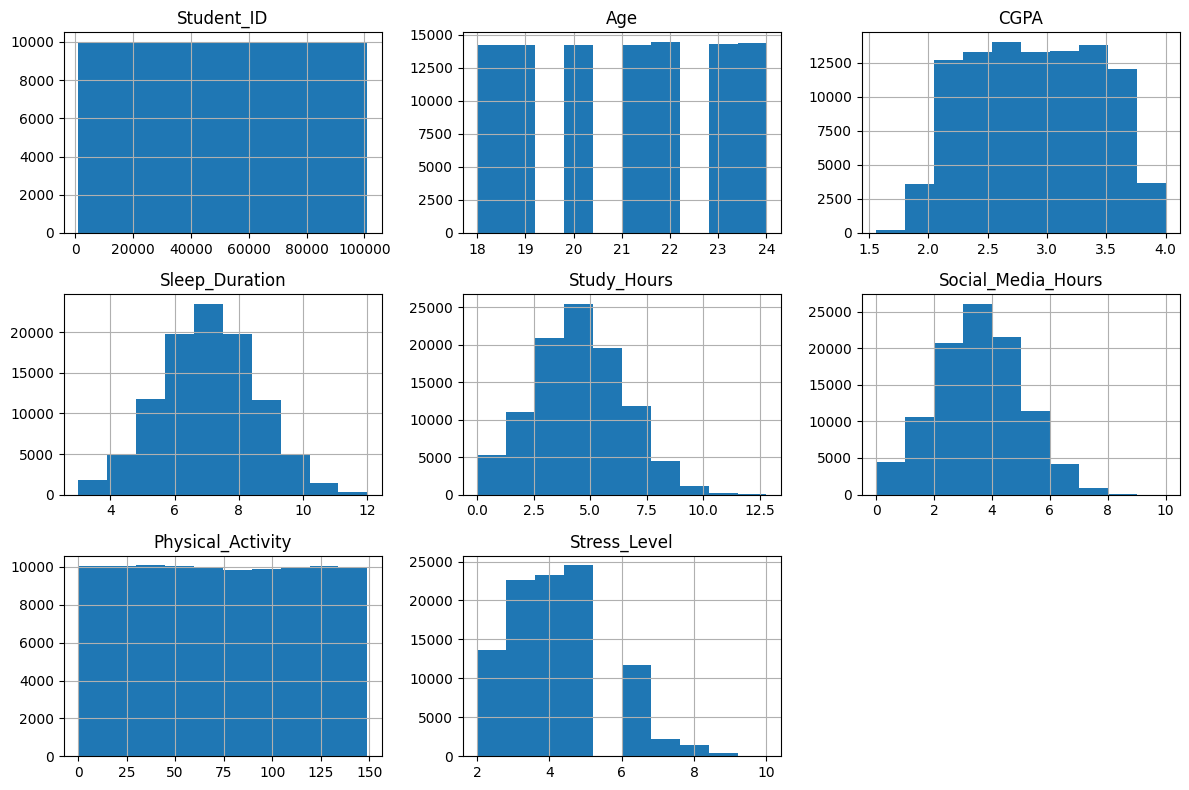

In [40]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


## 5. توزيع المتغير الهدف
نفحص توزيع المتغير الهدف (الاكتئاب) لفهم توازن البيانات.

Depression
False    89938
True     10062
Name: count, dtype: int64


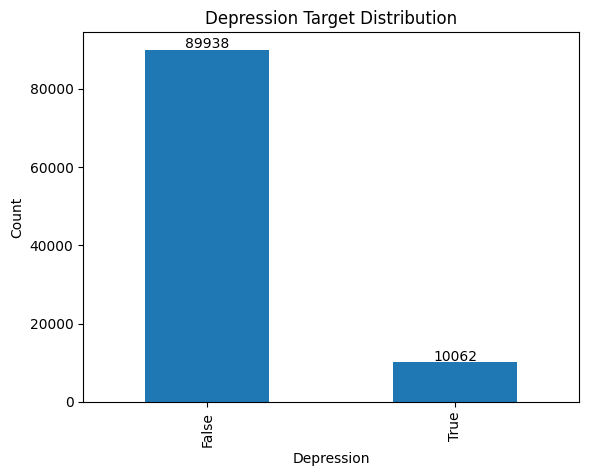

In [41]:
target_counts = df['Depression'].value_counts()

print(target_counts)

ax = target_counts.plot(kind='bar')

for i, v in enumerate(target_counts):
    ax.text(i, v + 500, str(v), ha='center')

plt.title("Depression Target Distribution")
plt.xlabel("Depression")
plt.ylabel("Count")

plt.show()



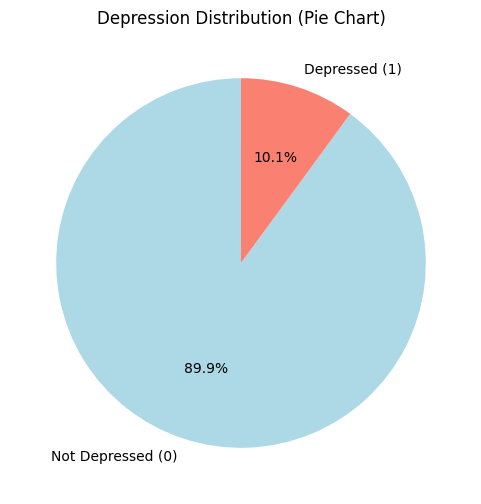

/var/folders/gf/dksb6pn134d9bgrs1zy3vmt00000gn/T/ipykernel_88704/1727163887.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette=['lightblue', 'salmon'])


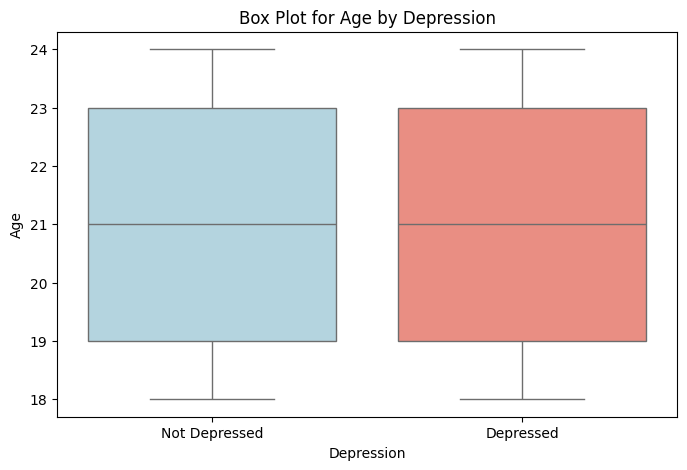

/var/folders/gf/dksb6pn134d9bgrs1zy3vmt00000gn/T/ipykernel_88704/1727163887.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette=['lightblue', 'salmon'])


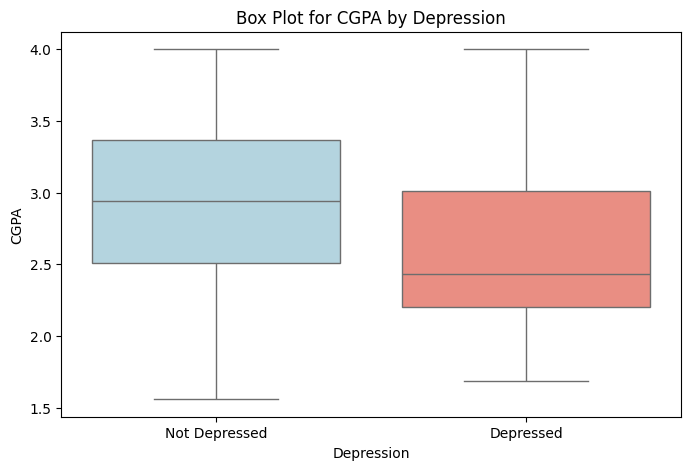

/var/folders/gf/dksb6pn134d9bgrs1zy3vmt00000gn/T/ipykernel_88704/1727163887.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette=['lightblue', 'salmon'])


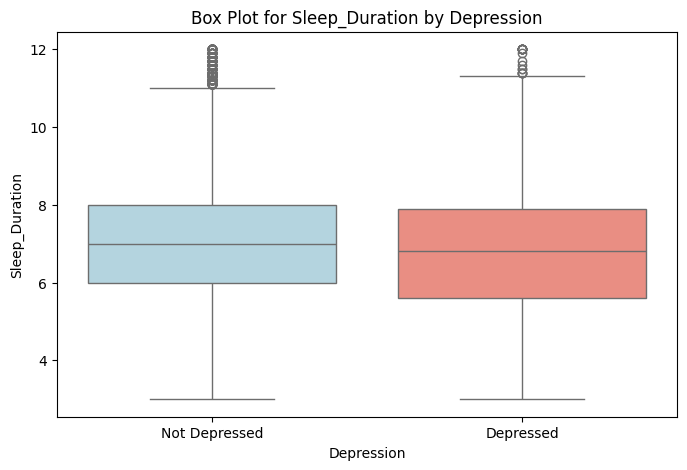

/var/folders/gf/dksb6pn134d9bgrs1zy3vmt00000gn/T/ipykernel_88704/1727163887.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette=['lightblue', 'salmon'])


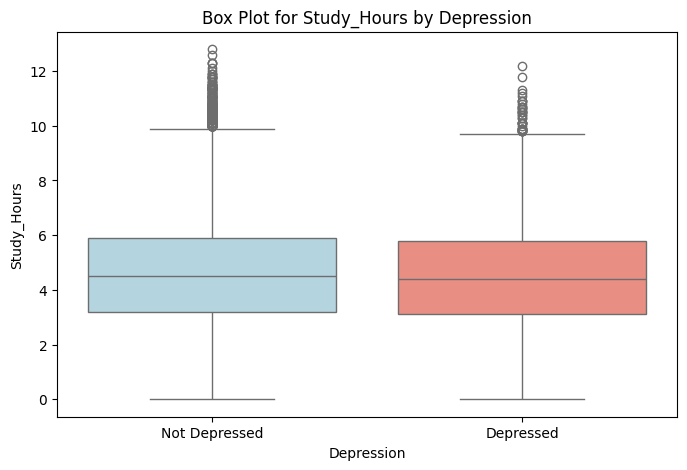

/var/folders/gf/dksb6pn134d9bgrs1zy3vmt00000gn/T/ipykernel_88704/1727163887.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette=['lightblue', 'salmon'])


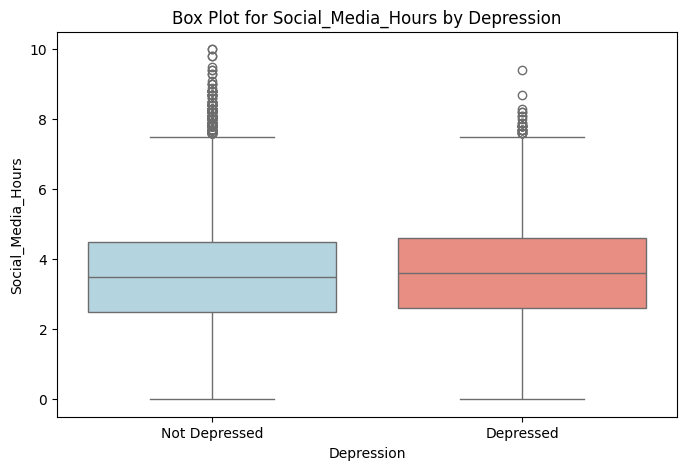

/var/folders/gf/dksb6pn134d9bgrs1zy3vmt00000gn/T/ipykernel_88704/1727163887.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette=['lightblue', 'salmon'])


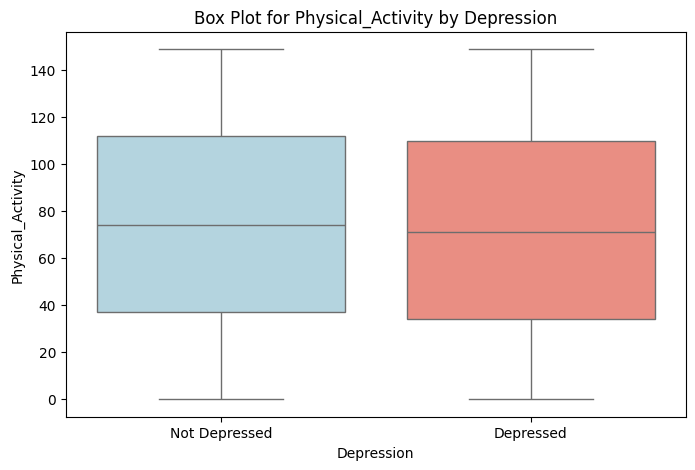

/var/folders/gf/dksb6pn134d9bgrs1zy3vmt00000gn/T/ipykernel_88704/1727163887.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette=['lightblue', 'salmon'])


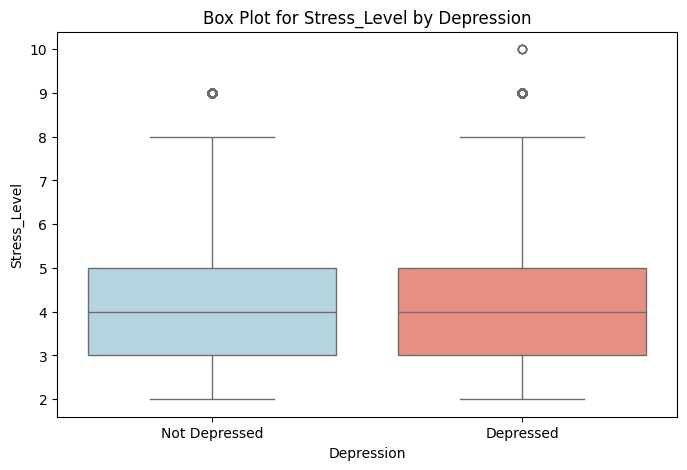

In [53]:
# رسم دائري لتوزيع الاكتئاب
plt.figure(figsize=(6, 6))
counts = df['Depression'].value_counts()
labels = ['Not Depressed (0)', 'Depressed (1)']
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
plt.title('Depression Distribution (Pie Chart)')
plt.show()

# مخططات صندوقية للخصائص الرقمية حسب الاكتئاب باستخدام Seaborn
numerical_cols = df.select_dtypes(include=['number']).columns.drop('Student_ID', errors='ignore')

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Depression', y=col, palette=['lightblue', 'salmon'])
    plt.title(f'Box Plot for {col} by Depression')
    plt.xticks([0, 1], ['Not Depressed', 'Depressed'])
    plt.show()

## 5.5 تحليلات بصرية إضافية
نضيف رسمًا دائريًا لتوزيع المتغير الهدف ومخططات صندوقية للخصائص الرقمية حسب الاكتئاب.

## 6. فحص القيم المفقودة
نتحقق من وجود أي قيم مفقودة في البيانات.

In [43]:
print(df.isnull().sum())


Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64


In [44]:
print("Number of duplicate rows:", df.duplicated().sum())

# فحص القيم الشاذة باستخدام IQR للأعمدة الرقمية
numerical_cols = df.select_dtypes(include=['number']).columns
print("\nOutliers detection using IQR:")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"Outliers in {col}: {outliers}")

Number of duplicate rows: 0

Outliers detection using IQR:
Outliers in Student_ID: 0
Outliers in Age: 0
Outliers in CGPA: 0
Outliers in Sleep_Duration: 369
Outliers in Study_Hours: 432
Outliers in Social_Media_Hours: 328
Outliers in Physical_Activity: 0
Outliers in Stress_Level: 478


## 6.5 التحقق من جودة البيانات الإضافية
نتحقق من التكرارات والقيم الشاذة لضمان جودة البيانات.

## 7. حذف العمود غير الضروري
نحذف عمود معرف الطالب لأنه غير مفيد للتنبؤ.

In [45]:
df.drop("Student_ID", axis=1, inplace=True)

print(df.head())
print(df.shape)


   Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0   22  Female      Science  3.50             7.3          3.3   
1   20    Male  Engineering  2.72             5.5          7.2   
2   20    Male      Medical  3.01             5.4          2.3   
3   21    Male  Engineering  3.63             8.1          2.0   
4   19    Male         Arts  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  
(100000, 10)


## 8. تصنيف الأعمدة
نصنف الأعمدة إلى فئوية ورقمية لمعرفة كيفية معالجتها.

In [46]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)



Categorical Columns:
Index(['Gender', 'Department'], dtype='str')

Numerical Columns:
Index(['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours',
       'Physical_Activity', 'Stress_Level'],
      dtype='str')


## 9. ترميز الأعمدة الفئوية
نحول الأعمدة الفئوية (الجنس والقسم) إلى أرقام باستخدام LabelEncoder.

In [47]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_department = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])
df['Department'] = le_department.fit_transform(df['Department'])

print(df.head())


   Age  Gender  Department  CGPA  Sleep_Duration  Study_Hours  \
0   22       0           4  3.50             7.3          3.3   
1   20       1           2  2.72             5.5          7.2   
2   20       1           3  3.01             5.4          2.3   
3   21       1           2  3.63             8.1          2.0   
4   19       1           0  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  


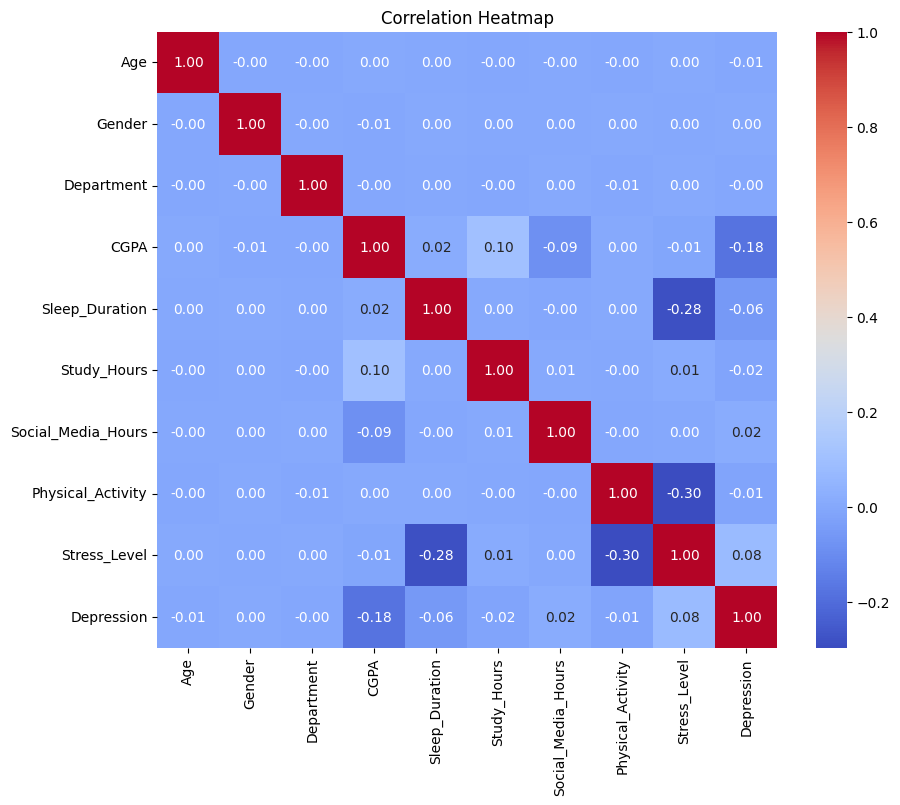

In [ ]:
# خريطة الارتباطات
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 9.5 خريطة الارتباطات
نعرض خريطة الارتباطات بين الخصائص بعد الترميز لفهم العلاقات.

## 10. ترميز المتغير الهدف
نحول المتغير الهدف إلى نوع عدد صحيح ونفحص توازنه.

In [49]:
df['Depression'] = df['Depression'].astype(int)

print(df.head())
print(df['Depression'].value_counts())

# البيانات غير متوازنة:
# الفئة 0 (غير مكتئب) تمثل تقريبًا 90%
# الفئة 1 (مكتئب) تمثل تقريبًا 10%
# لذلك سنركز لاحقًا على Recall و F1-score أكثر من Accuracy


   Age  Gender  Department  CGPA  Sleep_Duration  Study_Hours  \
0   22       0           4  3.50             7.3          3.3   
1   20       1           2  2.72             5.5          7.2   
2   20       1           3  3.01             5.4          2.3   
3   21       1           2  3.63             8.1          2.0   
4   19       1           0  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5           0  
1                 6.0                142             2           0  
2                 1.8                137             3           0  
3                 4.6                130             3           0  
4                 4.3                  4             6           0  
Depression
0    89938
1    10062
Name: count, dtype: int64


## 11. تقسيم الخصائص والمتغير الهدف
نقسم البيانات إلى مجموعات تدريب (80%)، تحقق (10%)، واختبار (10%) مع الحفاظ على التوازن.

In [50]:
X = df.drop("Depression", axis=1)
y = df["Depression"]

# أول تقسيم: 80% تدريب و20% مؤقتة
X_train, X_temp, y_train, y_temp = train_test_split(    
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ثاني تقسيم: 10% validation و10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)


X_train shape: (80000, 9)
X_val shape: (10000, 9)
X_test shape: (10000, 9)
y_train shape: (80000,)
y_val shape: (10000,)
y_test shape: (10000,)


## 12. توحيد مقياس الخصائص
نطبق StandardScaler لتوحيد الخصائص الرقمية لتحسين أداء النماذج.

In [51]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_val shape:", X_val_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)


Scaled X_train shape: (80000, 9)
Scaled X_val shape: (10000, 9)
Scaled X_test shape: (10000, 9)


## 13. إظهار أثر التوحيد بصريًا
نقارن توزيع إحدى الخصائص قبل وبعد التوحيد لتوضيح التأثير.

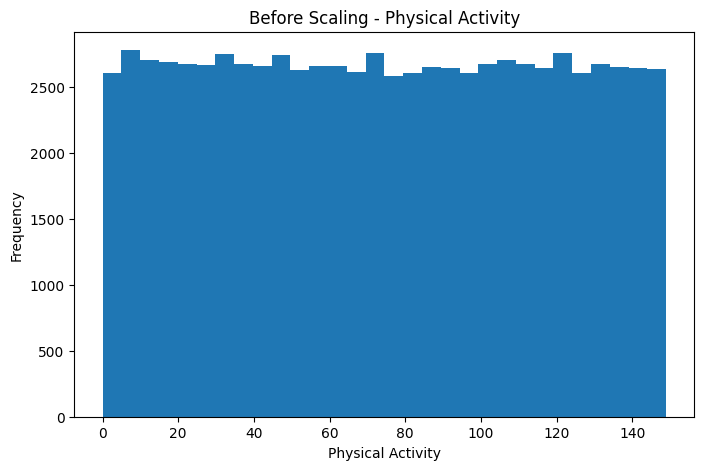

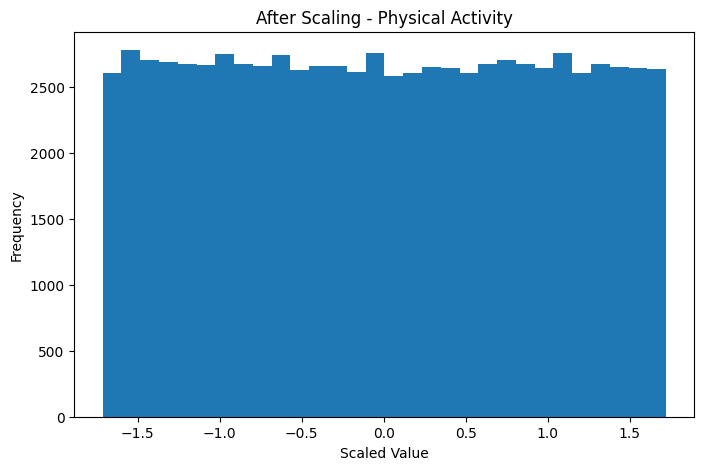

In [ ]:
# مقارنة التوزيع قبل وبعد التوحيد باستخدام مخططات فرعية
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# قبل التوحيد
axes[0].hist(X_train['Physical_Activity'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title("Before Scaling - Physical Activity")
axes[0].set_xlabel("Physical Activity")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)

# بعد التوحيد
axes[1].hist(X_train_scaled[:, list(X.columns).index('Physical_Activity')], bins=30, color='salmon', edgecolor='black')
axes[1].set_title("After Scaling - Physical Activity")
axes[1].set_xlabel("Scaled Value")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)


print(y_train.value_counts())
print(y_train_balanced.value_counts())

Depression
0    71950
1     8050
Name: count, dtype: int64
Depression
0    71950
1    71950
Name: count, dtype: int64


## 12.5 تطبيق SMOTE للتوازن
نستخدم SMOTE لزيادة عدد العينات في الفئة الأقل تكرارًا في مجموعة التدريب بعد التوحيد.

In [ ]:
import pickle
from imblearn.over_sampling import SMOTE

if "X_train_balanced" not in globals() or "y_train_balanced" not in globals():
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

with open("preprocessed_original.pkl", "wb") as f:
    pickle.dump(
        (
            X_train_scaled,
            X_val_scaled,
            X_test_scaled,
            y_train,
            y_val,
            y_test,
        ),
        f
    )

with open("preprocessed_smote.pkl", "wb") as f:
    pickle.dump(
        (
            X_train_balanced,
            X_val_scaled,
            X_test_scaled,
            y_train_balanced,
            y_val,
            y_test,
        ),
        f
    )

print("تم حفظ الملفين: preprocessed_original.pkl و preprocessed_smote.pkl")


In [ ]:
print("Original X_train shape:", X_train_scaled.shape)
print("Original y_train shape:", y_train.shape)
print("Balanced X_train shape:", X_train_balanced.shape)
print("Balanced y_train shape:", y_train_balanced.shape)